In [1]:
!pip install gymnasium numpy matplotlib

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

In [2]:
class MazeEnv(gym.Env):

    def __init__(self):
        super(MazeEnv, self).__init__()

        self.size = 5
        self.start = (0, 0)
        self.goal = (4, 4)

        self.walls = [(1,1), (1,2), (2,1), (3,3)]

        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.size * self.size)

        self.state = self.start

    def reset(self, seed=None):
        self.state = self.start
        return self._state_to_index(self.state), {}

    def step(self, action):
        x, y = self.state

        if action == 0:    # up
            x -= 1
        elif action == 1:  # down
            x += 1
        elif action == 2:  # left
            y -= 1
        elif action == 3:  # right
            y += 1

        next_state = (x, y)

        if self._is_valid(next_state):
            self.state = next_state

        reward = -1
        done = False

        if self.state == self.goal:
            reward = 100
            done = True

        return self._state_to_index(self.state), reward, done, False, {}

    def _is_valid(self, pos):
        x, y = pos
        if x < 0 or x >= self.size or y < 0 or y >= self.size:
            return False
        if pos in self.walls:
            return False
        return True

    def _state_to_index(self, state):
        return state[0] * self.size + state[1]

    def render(self):
        grid = np.zeros((self.size, self.size))
        for wall in self.walls:
            grid[wall] = -1
        grid[self.goal] = 2
        grid[self.state] = 1
        print(grid)

In [3]:
env = MazeEnv()

state_size = env.observation_space.n
action_size = env.action_space.n

Q = np.zeros((state_size, action_size))

In [4]:
alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 1000
max_steps = 100

In [5]:
rewards_per_episode = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):

        if np.random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, done, _, _ = env.step(action)

        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

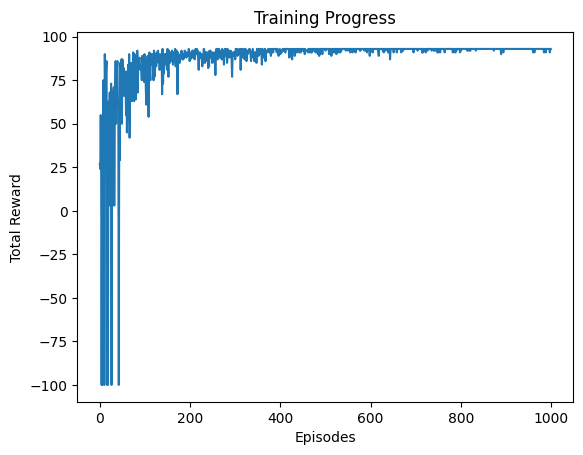

In [6]:
plt.plot(rewards_per_episode)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Training Progress")
plt.show()

In [7]:
policy = np.argmax(Q, axis=1)
policy.reshape(env.size, env.size)

array([[1, 3, 3, 3, 1],
       [1, 0, 0, 3, 1],
       [1, 0, 1, 3, 1],
       [1, 1, 1, 0, 1],
       [3, 3, 3, 3, 0]])

In [8]:
state, _ = env.reset()
env.render()

for _ in range(20):
    action = np.argmax(Q[state])
    state, reward, done, _, _ = env.step(action)
    env.render()
    if done:
        print("Goal reached")
        break

[[ 1.  0.  0.  0.  0.]
 [ 0. -1. -1.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  2.]]
[[ 0.  0.  0.  0.  0.]
 [ 1. -1. -1.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  2.]]
[[ 0.  0.  0.  0.  0.]
 [ 0. -1. -1.  0.  0.]
 [ 1. -1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  2.]]
[[ 0.  0.  0.  0.  0.]
 [ 0. -1. -1.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 1.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  2.]]
[[ 0.  0.  0.  0.  0.]
 [ 0. -1. -1.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.]
 [ 1.  0.  0.  0.  2.]]
[[ 0.  0.  0.  0.  0.]
 [ 0. -1. -1.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.]
 [ 0.  1.  0.  0.  2.]]
[[ 0.  0.  0.  0.  0.]
 [ 0. -1. -1.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.]
 [ 0.  0.  1.  0.  2.]]
[[ 0.  0.  0.  0.  0.]
 [ 0. -1. -1.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.]
 [ 0.  0.  0.  1.  2.]]
[[ 0.  0.  0.  0.  0.]
 [ 0. -1. -1.  0.  0.]
 [ 0. -1.  0.  0.  0.]
 [ 

In [9]:
success = 0
test_episodes = 100

for _ in range(test_episodes):
    state, _ = env.reset()

    for _ in range(max_steps):
        action = np.argmax(Q[state])
        state, reward, done, _, _ = env.step(action)
        if done:
            success += 1
            break

print("Success Rate:", success / test_episodes)

Success Rate: 1.0
